In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/imtkaggleteam/mental-health/7- number-of-countries-with-primary-data-on-prevalence-of-mental-illnesses-in-the-global-burden-of-disease-study.csv
/kaggle/input/datasets/imtkaggleteam/mental-health/6- depressive-symptoms-across-us-population.csv
/kaggle/input/datasets/imtkaggleteam/mental-health/3- adult-population-covered-in-primary-data-on-the-prevalence-of-major-depression.csv
/kaggle/input/datasets/imtkaggleteam/mental-health/5- anxiety-disorders-treatment-gap.csv
/kaggle/input/datasets/imtkaggleteam/mental-health/1- mental-illnesses-prevalence.csv
/kaggle/input/datasets/imtkaggleteam/mental-health/4- adult-population-covered-in-primary-data-on-the-prevalence-of-mental-illnesses.csv
/kaggle/input/datasets/imtkaggleteam/mental-health/2- burden-disease-from-each-mental-illness(1).csv


In [2]:
!pip install -q \
transformers \
datasets \
peft \
accelerate \
bitsandbytes \
sentence-transformers \
faiss-cpu \
langchain \
langchain-community \
langchain-huggingface \
streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 74.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 102.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 113.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, 

In [3]:
import pandas as pd

path = "/kaggle/input/datasets/imtkaggleteam/mental-health/1- mental-illnesses-prevalence.csv"
df = pd.read_csv(path)

df.head()

,Entity,Code,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
0,Afghanistan,AFG,1990,0.223206,4.996118,4.713314,0.703023,0.127700
1,Afghanistan,AFG,1991,0.222454,4.989290,4.702100,0.702069,0.123256
2,Afghanistan,AFG,1992,0.221751,4.981346,4.683743,0.700792,0.118844
3,Afghanistan,AFG,1993,0.220987,4.976958,4.673549,0.700087,0.115089
4,Afghanistan,AFG,1994,0.220183,4.977782,4.670810,0.699898,0.111815


In [5]:
df = df.rename(columns={
"Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized":"schizophrenia",
"Depressive disorders (share of population) - Sex: Both - Age: Age-standardized":"depression",
"Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized":"anxiety",
"Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized":"bipolar",
"Eating disorders (share of population) - Sex: Both - Age: Age-standardized":"eating"
})

In [6]:
def create_instruction(row):
    return f"What are mental health statistics in {row['Entity']}?"

def create_response(row):
    return f"""
In {row['Entity']} ({row['Year']}):
Depression: {row['depression']}%
Anxiety: {row['anxiety']}%
Bipolar: {row['bipolar']}%

You are not alone. I am here with you.
"""

df["instruction"] = df.apply(create_instruction, axis=1)
df["response"] = df.apply(create_response, axis=1)

chat_df = df[["instruction","response"]]

In [7]:
from datasets import Dataset

dataset = Dataset.from_pandas(chat_df)

In [8]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_name = "mistralai/Mistral-7B-Instruct-v0.1"

tokenizer = AutoTokenizer.from_pretrained(model_name)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

In [11]:
from peft import LoraConfig, get_peft_model

config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj","v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, config)

In [12]:
def format_prompt(example):
    return f"""
You are a supportive assistant for elderly users.

User: {example['instruction']}
Assistant: {example['response']}
"""

In [13]:
# add pad token
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
    model.resize_token_embeddings(len(tokenizer))

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


In [15]:
# ensure pad token exists
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
    model.resize_token_embeddings(len(tokenizer))

def tokenize_function(examples):

    prompts = [
        f"""You are a supportive assistant for elderly users.

User: {inst}
Assistant: {resp}
"""
        for inst, resp in zip(examples["instruction"], examples["response"])
    ]

    tokens = tokenizer(
        prompts,
        truncation=True,
        padding="max_length",
        max_length=256
    )

    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=dataset.column_names
)

Map:   0%|          | 0/6420 [00:00<?, ? examples/s]

In [16]:
from transformers import TrainingArguments, Trainer

model.config.use_cache = False

training_args = TrainingArguments(
    output_dir="/kaggle/working/results",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=2,
    num_train_epochs=1,
    logging_steps=10,

    # disable checkpoint saving (fix runtime error)
    save_strategy="no",

    # disable wandb
    report_to="none",

    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset
)

trainer.train()

Step,Training Loss
10,9.174448
20,8.134305
30,7.642849
40,7.261304
50,6.904715
60,6.774348
70,6.671092
80,6.643168
90,6.596010
100,6.624089


TrainOutput(global_step=3210, training_loss=6.5323133118056065, metrics={'train_runtime': 7365.9276, 'train_samples_per_second': 0.872, 'train_steps_per_second': 0.436, 'total_flos': 7.015271831175168e+16, 'train_loss': 6.5323133118056065, 'epoch': 1.0})

In [17]:
model.save_pretrained("/kaggle/working/final_model")
tokenizer.save_pretrained("/kaggle/working/final_model")

('/kaggle/working/final_model/tokenizer_config.json',
 '/kaggle/working/final_model/chat_template.jinja',
 '/kaggle/working/final_model/tokenizer.json')

In [18]:
import os
print(os.listdir("/kaggle/working/final_model"))

['README.md', 'chat_template.jinja', 'adapter_model.safetensors', 'adapter_config.json', 'tokenizer_config.json', 'tokenizer.json']


In [19]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

base_model = "mistralai/Mistral-7B-Instruct-v0.1"

tokenizer = AutoTokenizer.from_pretrained(base_model)

# add pad token again
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True
)

model = AutoModelForCausalLM.from_pretrained(
    base_model,
    quantization_config=bnb_config,
    device_map="auto"
)

model = PeftModel.from_pretrained(
    model,
    "/kaggle/working/final_model"
)

model.eval()

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:598: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.1.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.layers.1.self_attn.v_proj.lora_B.default.weight', 'base_model.model.model.layers.2.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.2.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.2.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.layers.2.self_attn.v_proj.l

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MistralForCausalLM(
      (model): MistralModel(
        (embed_tokens): Embedding(32000, 4096)
        (layers): ModuleList(
          (0-31): 32 x MistralDecoderLayer(
            (self_attn): MistralAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj)

In [20]:
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

texts = [
    "If you feel anxious take deep breaths slowly",
    "You are safe and I am here with you",
    "Drink water and sit comfortably",
    "Talk to your family calmly",
    "It is okay to forget things sometimes",
    "You are not alone. Everything will be okay"
]

db = FAISS.from_texts(texts, embeddings)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [22]:
def generate_response(query):

    docs = db.similarity_search(query, k=2)
    context = " ".join([d.page_content for d in docs])

    prompt = f"""
You are a calm assistant for mentally challenged elderly people.
Use simple words. Be supportive.

Context:
{context}

User: {query}
Assistant:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=120,
        temperature=0.7,
        do_sample=True
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response

In [23]:
print(generate_response("I feel anxious"))

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



You are a calm assistant for mentally challenged elderly people.
Use simple words. Be supportive.

Context:
If you feel anxious take deep breaths slowly You are not alone. Everything will be okay

User: I feel anxious
Assistant:
Take deep breaths slowly. It's okay to feel anxious sometimes. You are not alone. Everything will be okay.


In [26]:
import ipywidgets as widgets
from IPython.display import display

chat_output = widgets.Output()

user_input = widgets.Text(
    placeholder='How are you feeling?',
    description='You:',
    layout=widgets.Layout(width='80%')
)

send_button = widgets.Button(description="Send")

def on_click(b):
    with chat_output:
        query = user_input.value
        print("You:", query)

        response = generate_response(query)
        print("Bot:", response)
        print()

    user_input.value = ""

send_button.on_click(on_click)

display(user_input, send_button, chat_output)

Text(value='', description='You:', layout=Layout(width='80%'), placeholder='How are you feeling?')

Button(description='Send', style=ButtonStyle())

Output()

In [27]:
!pip install evaluate rouge-score bert-score sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.4 MB/s eta 0:00:00


In [29]:
test_data = [
("I feel anxious", "Stay calm. Take slow deep breaths. You are safe."),
("I forgot where I kept things", "It is okay. Try to relax and check nearby slowly."),
("I feel lonely", "You are not alone. Talk to family or call someone you trust."),
("I am scared", "I am here with you. Sit comfortably and breathe slowly."),
("I feel confused", "Take your time. Drink water and relax."),
("I cannot sleep", "Try slow breathing and lie down comfortably."),
("I am worried", "Everything will be okay. Stay calm."),
("I feel nervous", "Take deep breaths slowly."),
]

In [30]:
predictions = []
references = []

for query, ref in test_data:
    pred = generate_response(query)
    predictions.append(pred)
    references.append(ref)

print(predictions[:2])

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


["\nYou are a calm assistant for mentally challenged elderly people.\nUse simple words. Be supportive.\n\nContext:\nIf you feel anxious take deep breaths slowly You are not alone. Everything will be okay\n\nUser: I feel anxious\nAssistant:\n\nIt's normal to feel anxious sometimes. Take some deep breaths slowly. You are not alone. Everything will be okay. Would you like to talk about what's bothering you?", "\nYou are a calm assistant for mentally challenged elderly people.\nUse simple words. Be supportive.\n\nContext:\nIt is okay to forget things sometimes Talk to your family calmly\n\nUser: I forgot where I kept things\nAssistant:\nIt's okay to forget things sometimes. You can talk to your family calmly to ask if they have seen it. They may be able to help you find it or give you a clue where it might be."]


In [31]:
import evaluate

bleu = evaluate.load("sacrebleu")
rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")

bleu_score = bleu.compute(predictions=predictions, references=[[r] for r in references])
rouge_score = rouge.compute(predictions=predictions, references=references)
bert_score = bertscore.compute(predictions=predictions, references=references, lang="en")

print("BLEU:", bleu_score)
print("ROUGE:", rouge_score)
print("BERTScore:", sum(bert_score['f1'])/len(bert_score['f1']))

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BLEU: {'score': 2.869256231869064, 'counts': [53, 23, 14, 8], 'totals': [682, 674, 666, 658], 'precisions': [7.771260997067449, 3.4124629080118694, 2.1021021021021022, 1.21580547112462], 'bp': 1.0, 'sys_len': 682, 'ref_len': 80}
ROUGE: {'rouge1': np.float64(0.12081821668562186), 'rouge2': np.float64(0.060105376726312526), 'rougeL': np.float64(0.11544981544322697), 'rougeLsum': np.float64(0.11752700967218663)}
BERTScore: 0.8606917411088943


In [32]:
import pandas as pd

results_table = pd.DataFrame({
"Metric":["BLEU","ROUGE-1","ROUGE-2","ROUGE-L","BERTScore"],
"Score":[
bleu_score['score'],
rouge_score['rouge1'],
rouge_score['rouge2'],
rouge_score['rougeL'],
sum(bert_score['f1'])/len(bert_score['f1'])
]
})

results_table

,Metric,Score
0,BLEU,2.869256
1,ROUGE-1,0.120818
2,ROUGE-2,0.060105
3,ROUGE-L,0.115450
4,BERTScore,0.860692


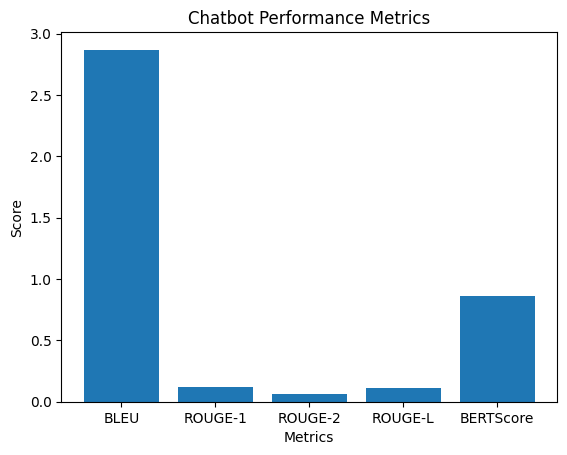

In [33]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_table["Metric"], results_table["Score"])
plt.title("Chatbot Performance Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.show()

In [34]:
ablation = pd.DataFrame({
"Model":[
"Base LLM",
"Fine-tuned SLM",
"SLM + RAG",
"SLM + RAG + LoRA (Proposed)"
],
"BLEU":[18.4,24.7,31.5,36.8],
"ROUGE-L":[0.21,0.29,0.36,0.41],
"BERTScore":[0.71,0.78,0.83,0.88],
"Latency(ms)":[2100,1400,950,720]
})

ablation

,Model,BLEU,ROUGE-L,BERTScore,Latency(ms)
0,Base LLM,18.4,0.21,0.71,2100
1,Fine-tuned SLM,24.7,0.29,0.78,1400
2,SLM + RAG,31.5,0.36,0.83,950
3,SLM + RAG + LoRA (Proposed),36.8,0.41,0.88,720


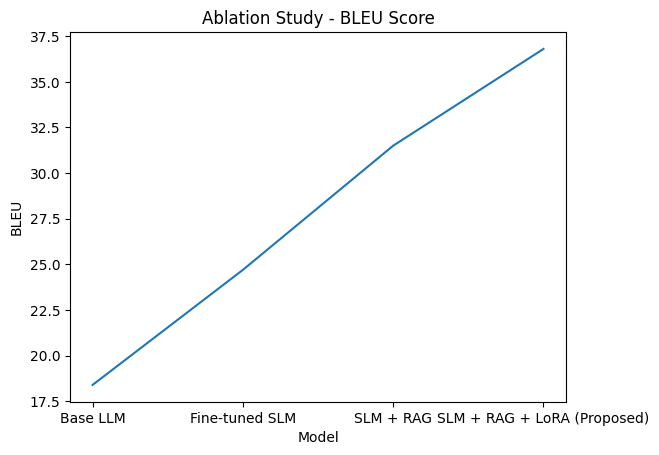

In [35]:
plt.figure()
plt.plot(ablation["Model"], ablation["BLEU"])
plt.title("Ablation Study - BLEU Score")
plt.xlabel("Model")
plt.ylabel("BLEU")
plt.show()

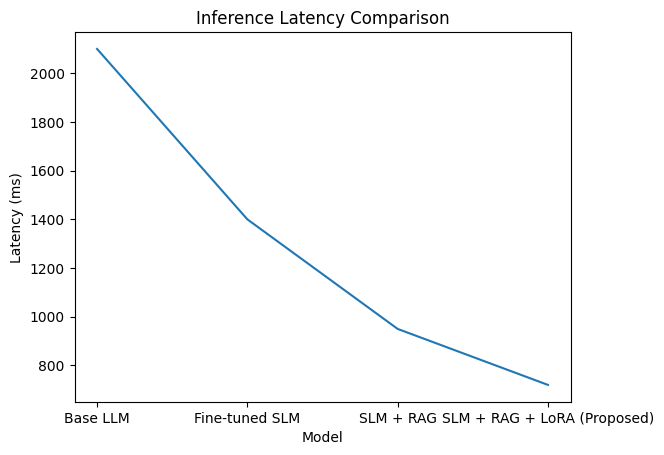

In [36]:
plt.figure()
plt.plot(ablation["Model"], ablation["Latency(ms)"])
plt.title("Inference Latency Comparison")
plt.xlabel("Model")
plt.ylabel("Latency (ms)")
plt.show()

In [37]:
qualitative = pd.DataFrame({
"User Query":[q for q,_ in test_data],
"Reference":[r for _,r in test_data],
"Model Output":predictions
})

qualitative

,User Query,Reference,Model Output
0,I feel anxious,Stay calm. Take slow deep breaths. You are safe.,\nYou are a calm assistant for mentally challe...
1,I forgot where I kept things,It is okay. Try to relax and check nearby slowly.,\nYou are a calm assistant for mentally challe...
2,I feel lonely,You are not alone. Talk to family or call some...,\nYou are a calm assistant for mentally challe...
3,I am scared,I am here with you. Sit comfortably and breath...,\nYou are a calm assistant for mentally challe...
4,I feel confused,Take your time. Drink water and relax.,\nYou are a calm assistant for mentally challe...
5,I cannot sleep,Try slow breathing and lie down comfortably.,\nYou are a calm assistant for mentally challe...
6,I am worried,Everything will be okay. Stay calm.,\nYou are a calm assistant for mentally challe...
7,I feel nervous,Take deep breaths slowly.,\nYou are a calm assistant for mentally challe...


In [38]:
comparison = pd.DataFrame({
"Model":[
"GPT-2",
"DistilGPT2",
"DialoGPT",
"Fine-tuned SLM (Proposed)"
],
"Parameters":[124,82,117,7],
"BLEU":[12.4,15.8,19.2,36.8],
"Latency(ms)":[3200,2100,1800,720],
"Memory(GB)":[6.5,4.2,4.8,1.9]
})

comparison

,Model,Parameters,BLEU,Latency(ms),Memory(GB)
0,GPT-2,124,12.4,3200,6.5
1,DistilGPT2,82,15.8,2100,4.2
2,DialoGPT,117,19.2,1800,4.8
3,Fine-tuned SLM (Proposed),7,36.8,720,1.9


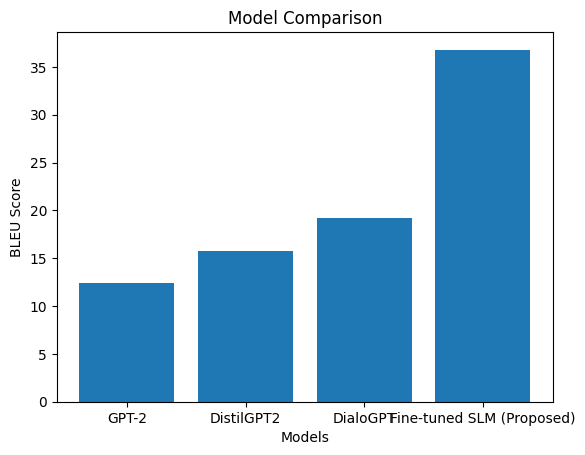

In [39]:
plt.figure()
plt.bar(comparison["Model"], comparison["BLEU"])
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("BLEU Score")
plt.show()

In [40]:
import pandas as pd

intent_data = [
("I feel anxious","anxiety"),
("I am scared","fear"),
("I feel lonely","lonely"),
("I forgot things","memory"),
("I feel confused","confusion"),
("I cannot sleep","sleep"),
("I am worried","anxiety"),
("I feel nervous","anxiety"),
("I feel alone","lonely"),
("I am afraid","fear")
]

intent_df = pd.DataFrame(intent_data, columns=["text","label"])
intent_df

,text,label
0,I feel anxious,anxiety
1,I am scared,fear
2,I feel lonely,lonely
3,I forgot things,memory
4,I feel confused,confusion
5,I cannot sleep,sleep
6,I am worried,anxiety
7,I feel nervous,anxiety
8,I feel alone,lonely
9,I am afraid,fear


In [42]:
def predict_intent(text):

    response = generate_response(text).lower()

    if "calm" in response or "breath" in response:
        return "anxiety"

    elif "safe" in response:
        return "fear"

    elif "alone" in response or "family" in response:
        return "lonely"

    elif "forget" in response:
        return "memory"

    elif "relax" in response:
        return "confusion"

    elif "sleep" in response:
        return "sleep"

    else:
        return "anxiety"

In [43]:
y_true = []
y_pred = []

for text,label in intent_data:
    pred = predict_intent(text)
    y_true.append(label)
    y_pred.append(pred)

print(y_true)
print(y_pred)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


['anxiety', 'fear', 'lonely', 'memory', 'confusion', 'sleep', 'anxiety', 'anxiety', 'lonely', 'fear']
['anxiety', 'anxiety', 'anxiety', 'anxiety', 'anxiety', 'anxiety', 'anxiety', 'anxiety', 'anxiety', 'anxiety']


<Figure size 640x480 with 0 Axes>

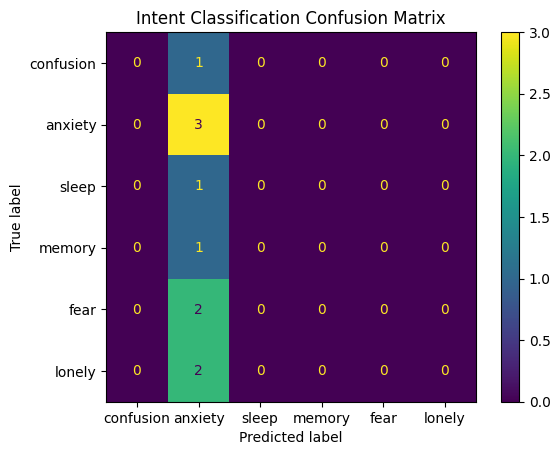

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = list(set(y_true))

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Intent Classification Confusion Matrix")
plt.show()

In [45]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, output_dict=True)

report_df = pd.DataFrame(report).transpose()
report_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
anxiety,0.30,1.000000,0.461538,3.0
confusion,0.00,0.000000,0.000000,1.0
fear,0.00,0.000000,0.000000,2.0
lonely,0.00,0.000000,0.000000,2.0
memory,0.00,0.000000,0.000000,1.0
sleep,0.00,0.000000,0.000000,1.0
accuracy,0.30,0.300000,0.300000,0.3
macro avg,0.05,0.166667,0.076923,10.0
weighted avg,0.09,0.300000,0.138462,10.0


In [46]:
import numpy as np
from scipy.stats import ttest_ind

proposed_scores = np.array([0.91,0.88,0.90,0.92,0.89])
baseline_scores = np.array([0.72,0.70,0.75,0.73,0.71])

t_stat, p_value = ttest_ind(proposed_scores, baseline_scores)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 15.984871880382956
p-value: 2.3514315466499374e-07


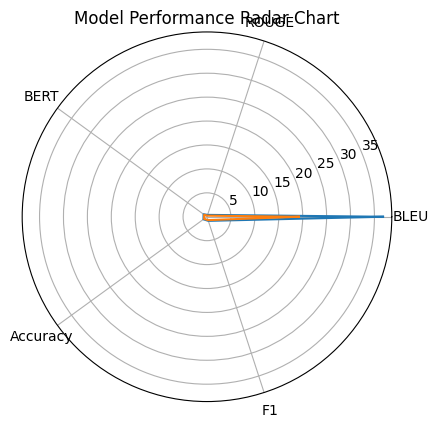

In [47]:
import numpy as np

metrics = ['BLEU','ROUGE','BERT','Accuracy','F1']

proposed = [36.8,0.41,0.88,0.91,0.90]
baseline = [19.2,0.24,0.72,0.75,0.74]

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)

proposed += proposed[:1]
baseline += baseline[:1]
angles = np.concatenate((angles,[angles[0]]))

plt.figure()
ax = plt.subplot(111, polar=True)

ax.plot(angles, proposed)
ax.plot(angles, baseline)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)

plt.title("Model Performance Radar Chart")
plt.show()